# Catalog-level BAO/AP blinding example

This notebook demonstrates the small, generic catalog-level BAO/AP redshift
remapping API in `desiblind.CatalogBAOBlinder`.

This is separate from the power-spectrum/bispectrum data-vector blinding shown
in `nb/blinding_example_new.ipynb`: here we transform catalog redshifts. DESI
pipeline code or validation drivers still handle file discovery, `LSScats/`
naming, region splitting, and job orchestration.

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Prefer the local checkout when this notebook is run from the repository.
repo_root = Path.cwd()
if not (repo_root / "desiblind").exists():
    repo_root = repo_root.parent
if (repo_root / "desiblind").exists():
    sys.path.insert(0, str(repo_root))

from desiblind import CatalogBAOBlinder

%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Redshift-array API

For a bare redshift array, pass a canonical tracer-bin name and explicit BAO/AP
parameters.

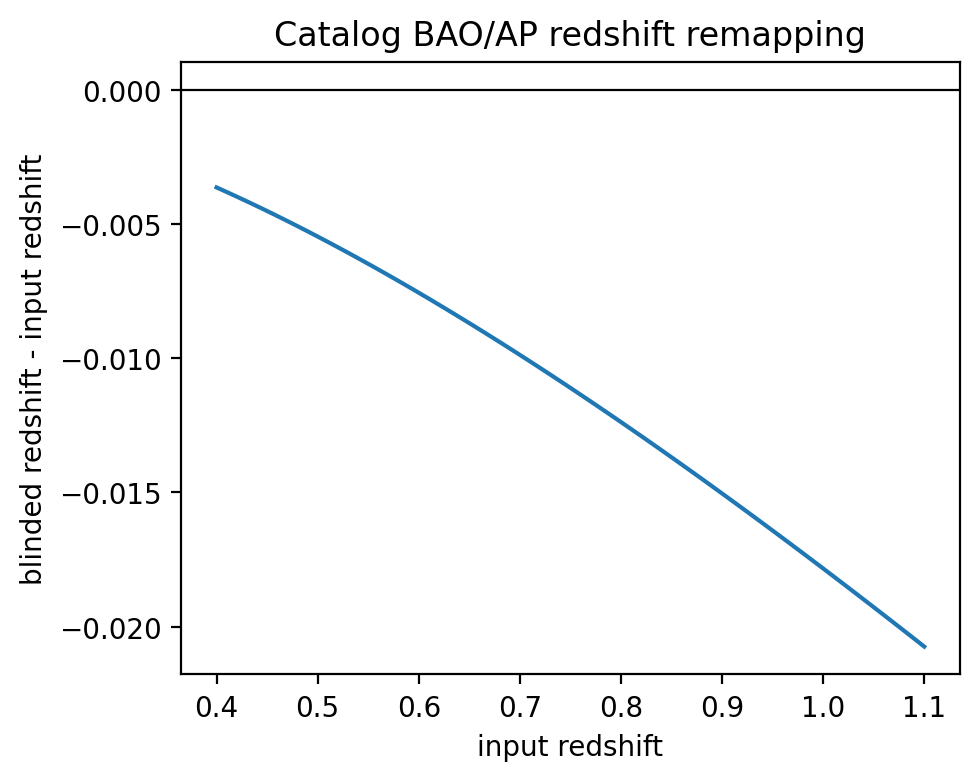

In [2]:
params = {'w0': -0.95, 'wa': 0.10}
z = np.linspace(0.4, 1.1, 64)

z_blinded = CatalogBAOBlinder.apply_blinding('LRG3', z, parameters=params)
z_unblinded = CatalogBAOBlinder.remove_blinding('LRG3', z_blinded, parameters=params, force=True)

np.testing.assert_allclose(z_unblinded, z, rtol=0, atol=1e-9)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(z, z_blinded - z)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('input redshift')
ax.set_ylabel('blinded redshift - input redshift')
ax.set_title('Catalog BAO/AP redshift remapping')
fig.tight_layout()
fig.show()

## Catalog-like API

Catalog objects can be any object that supports `copy()`, column access, and
column assignment.  A plain dictionary is enough for this toy example; production
DESI workflows typically use a `mockfactory`/Cosmodesi catalog-like object.

For the LSS full-catalog convention, the source and destination columns can be
different: transform `Z_not4clus` and write the blinded redshift into `Z`.

In [3]:
toy_catalog = {
    'RA': np.linspace(150., 155., z.size),
    'DEC': np.linspace(10., 12., z.size),
    'Z_not4clus': z,
    'Z': z.copy(),
}

blinded_catalog = CatalogBAOBlinder.apply_blinding(
    'LRG3',
    toy_catalog,
    parameters=params,
    input_zcol='Z_not4clus',
    output_zcol='Z',
)

np.testing.assert_allclose(blinded_catalog['Z'], z_blinded)
np.testing.assert_allclose(blinded_catalog['Z_not4clus'], toy_catalog['Z_not4clus'])

print('input columns:', sorted(toy_catalog))
print('blinded Z first three:', blinded_catalog['Z'][:3])

input columns: ['DEC', 'RA', 'Z', 'Z_not4clus']
blinded Z first three: [0.39635353 0.40727589 0.41819446]


## Private parameter-bank API

Blind parameters can also be written and loaded from a private NumPy dictionary
using the same hash-key convention as the summary-statistic shifts.

In [4]:
with tempfile.TemporaryDirectory() as tmpdir:
    save_fn = CatalogBAOBlinder.write_blinded_parameters('LRG3', params, save_dir=tmpdir)
    loaded = CatalogBAOBlinder.load_blinded_parameters('LRG3', save_dir=tmpdir)

print('parameter bank file:', Path(save_fn).name)
print('loaded parameters:', loaded)
assert loaded == params

parameter bank file: catalog_blinding_parameters.npy
loaded parameters: {'w0': -0.95, 'wa': 0.1}


## Validation reference

The full LSS comparison and final Pk/xi validation ladder is in:

```text
scripts/validation/catalog_bao_validation.ipynb
```

That notebook is the validation product; this notebook is only the compact API
example.